In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import shap
import statsmodels.api as sm
import pickle

sys.path.insert(0, "../utils")

from modules import *

from sklearn.metrics import  mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [7]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

In [8]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [10]:
dataframe['case_bin'] = bins

In [11]:
# dataset = pd.concat([data_0, data_rest])

dataset = dataframe.copy()

In [12]:
dataset['dt_temp'] = dataset['dt_prediction']+3
dataset['year'] = dataset['dt_temp'].dt.year
dataset['year'] = pd.Categorical(dataset['year'])
dataset.drop(columns=['dt_temp'], inplace=True)

In [13]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [14]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256  512 1024 8192]


In [15]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '0'),
 Text(1, 0, '[1-8]'),
 Text(2, 0, '(8-16]'),
 Text(3, 0, '(16-32]'),
 Text(4, 0, '(32-64]'),
 Text(5, 0, '(64-128]'),
 Text(6, 0, '(128-256]'),
 Text(7, 0, '(256-512]'),
 Text(8, 0, '(512-1024]'),
 Text(9, 0, '1024+')]

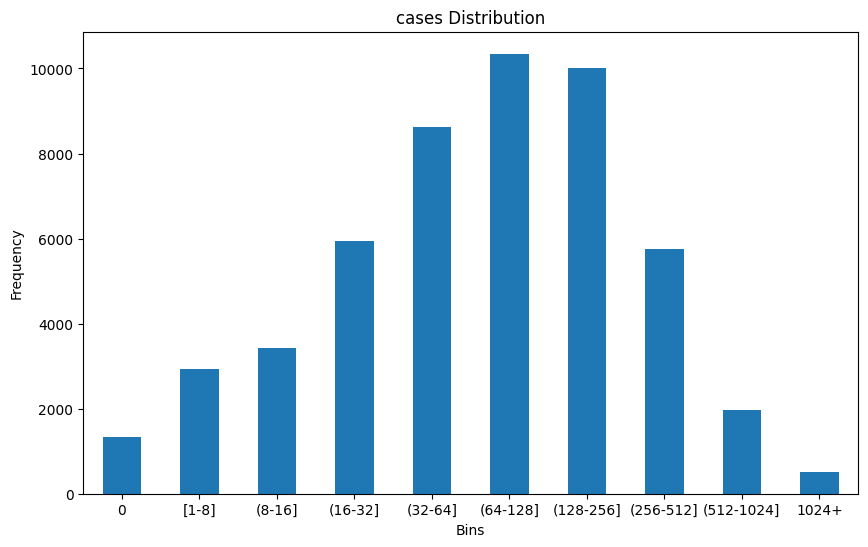

In [16]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['0', '[1-8]', '(8-16]', '(16-32]','(32-64]','(64-128]','(128-256]','(256-512]','(512-1024]','1024+'], rotation=0) 
        

In [17]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin,year
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94,5,2015
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7,1,2015
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91,5,2015
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31,3,2015
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109,5,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50834,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,59,4,2024
50835,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,126,5,2024
50836,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,656,8,2024
50837,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,403,7,2024


In [18]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin', 'year'])
y = dataset['case_bin']

k_fold = CategoricalKFold(col='year')

In [19]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [20]:
with open("rfecv_model.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [21]:
model_params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.3,
    'n_estimators': 200, 
    'min_child_weight': 4,
    'gamma': 0,
    'random_state': 0
}

In [22]:
y_train_list = []
y_test_list = []
y_train_pred_list = []
y_test_pred_list = []
fold_counter = 0

shap_values_list = []
test_idx_list = []


for train_idx, test_idx in k_fold.split(dataset):
    print(f'Fold: {fold_counter+1} | Year: {dataset.iloc[test_idx].year.unique().tolist()}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    model = xgb.XGBRegressor(**model_params)   
    fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

    y_train_pred = fitted_model.predict(X_train_rfe)
    y_test_pred = fitted_model.predict(X_test_rfe)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_pred_list.append(y_train_pred)
    y_test_pred_list.append(y_test_pred)

    # SHAP TreeExplainer for XGBRegressor
    explainer = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_test_rfe)
    shap_values_list.append(shap_values)
    test_idx_list.append(test_idx)

    fold_counter += 1

Fold: 1 | Year: [2015]


Fold: 2 | Year: [2016]
Fold: 3 | Year: [2017]
Fold: 4 | Year: [2018]
Fold: 5 | Year: [2019]
Fold: 6 | Year: [2020]
Fold: 7 | Year: [2021]
Fold: 8 | Year: [2022]
Fold: 9 | Year: [2023]
Fold: 10 | Year: [2024]


In [23]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_pred = np.concatenate(y_train_pred_list, axis = 0)
y_test_pred = np.concatenate(y_test_pred_list, axis = 0)

y_train_pred = np.clip(np.round(y_train_pred), 0, 9).astype(int)
y_test_pred = np.clip(np.round(y_test_pred), 0, 9).astype(int)

In [24]:
results_train = pd.DataFrame({'actual': y_train_true,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test_true,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [25]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.4683
MSE on train set: 0.5693
min prediction: 0
max prediction: 9

MAE on test set: 0.9286
MSE on test set: 1.6785
Error <= 1: 79.72 %
min prediction: 0
max prediction: 9


In [26]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [27]:
plot_hist_plotly(results_test['actual'], results_test['prediction'])

In [28]:
test_set = np.concatenate(test_idx_list)
shap_values = np.vstack(shap_values_list)
X_test = pd.DataFrame(X.iloc[test_set],columns=X.columns[fitted_rfe.support_])

In [29]:
tree_shap_values_df = pd.DataFrame(shap_values, columns=X.columns[fitted_rfe.support_], index=test_set)

sorted_mean_abs_values_idx = tree_shap_values_df.abs().mean().sort_values(ascending=False).index

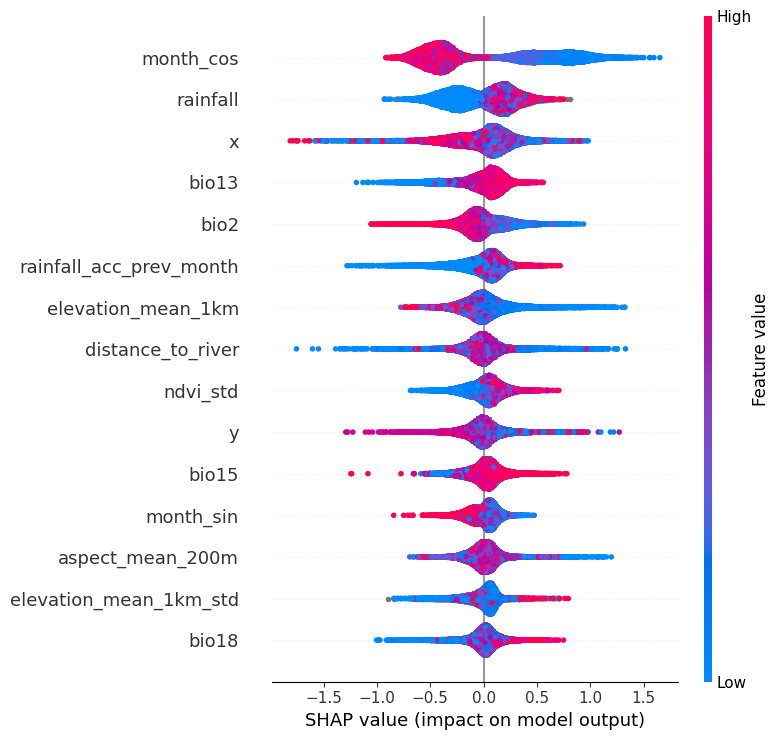

In [30]:
shap.summary_plot(shap_values, X_test, max_display=15)

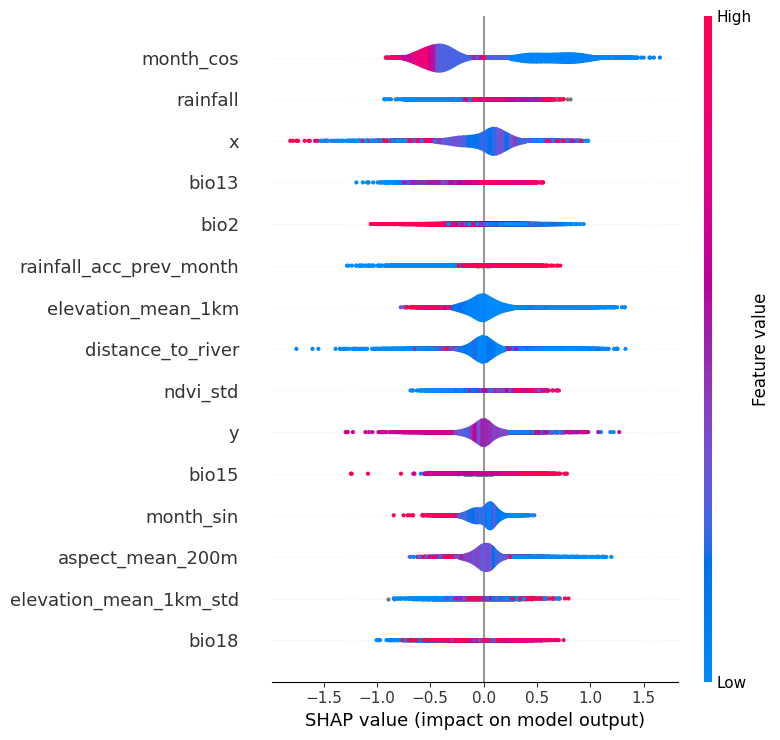

In [31]:
shap.summary_plot(shap_values, X_test, plot_type='violin', max_display=15)

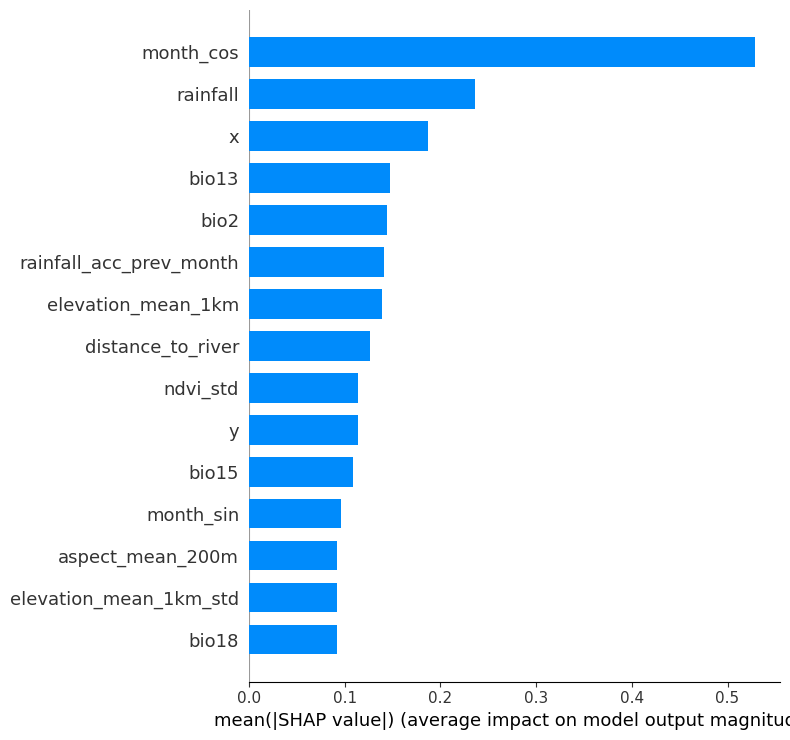

In [32]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

In [33]:
shap_lim = (-2, 2)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

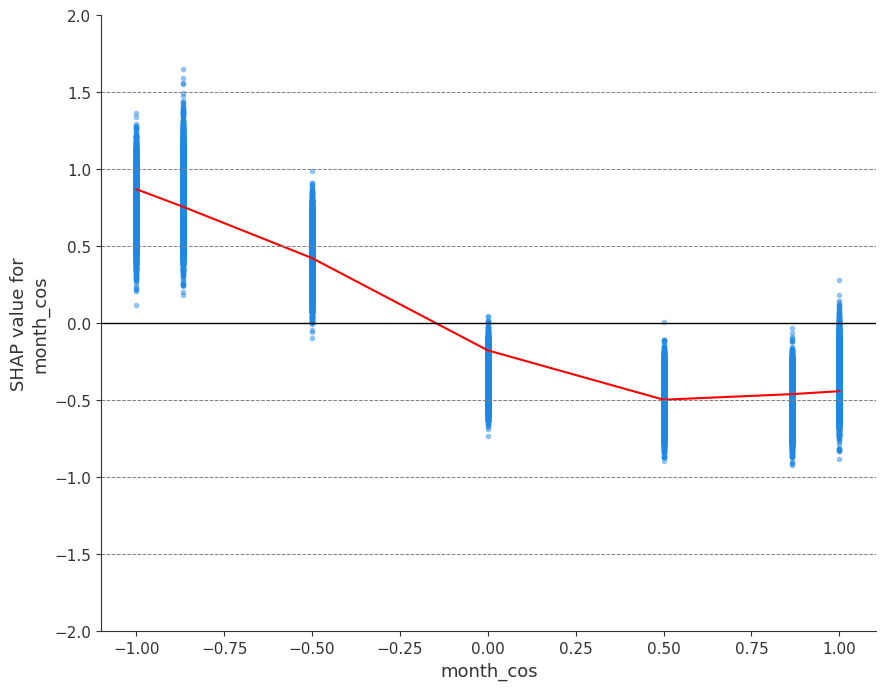

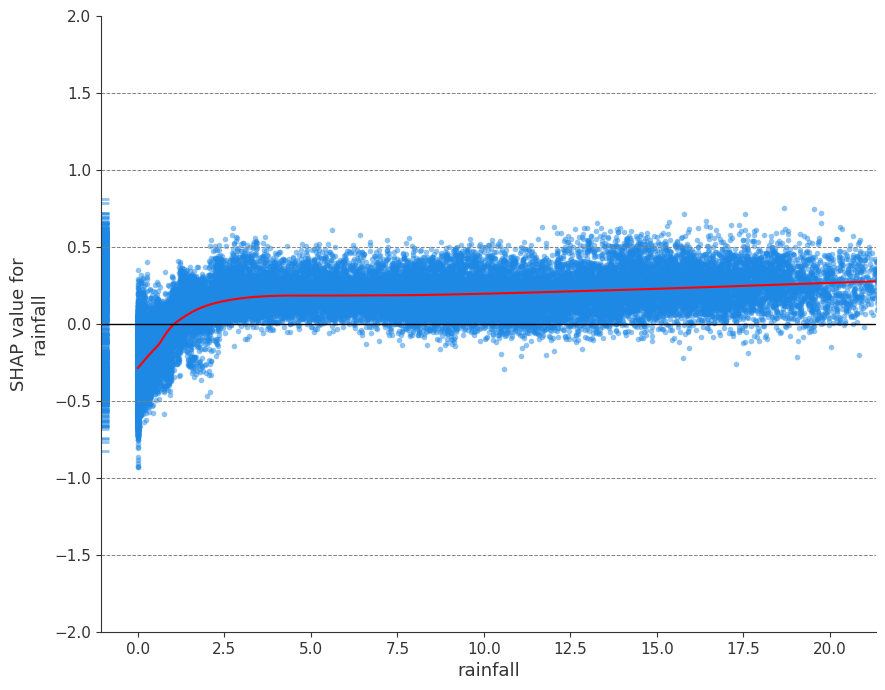

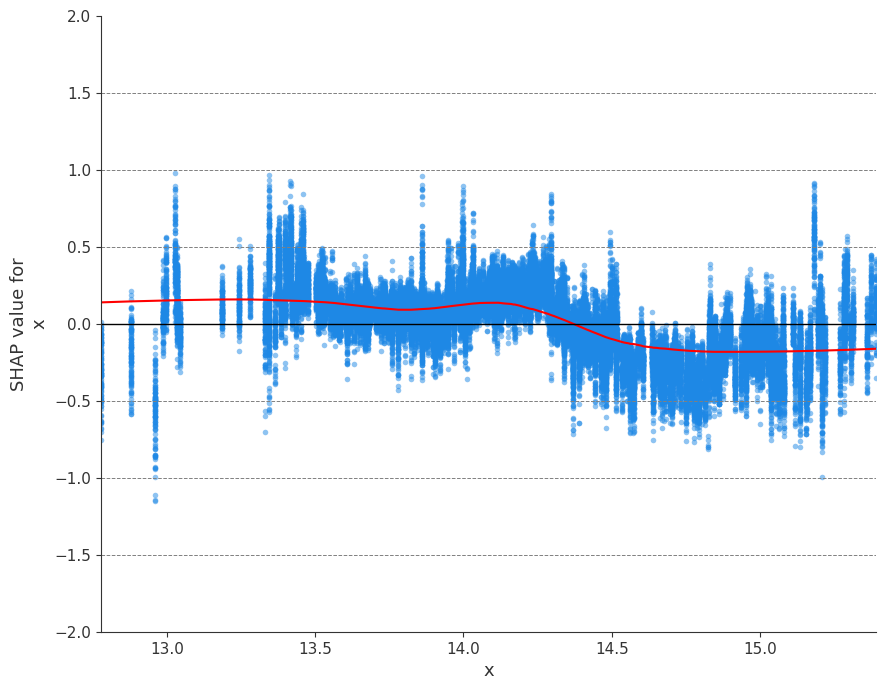

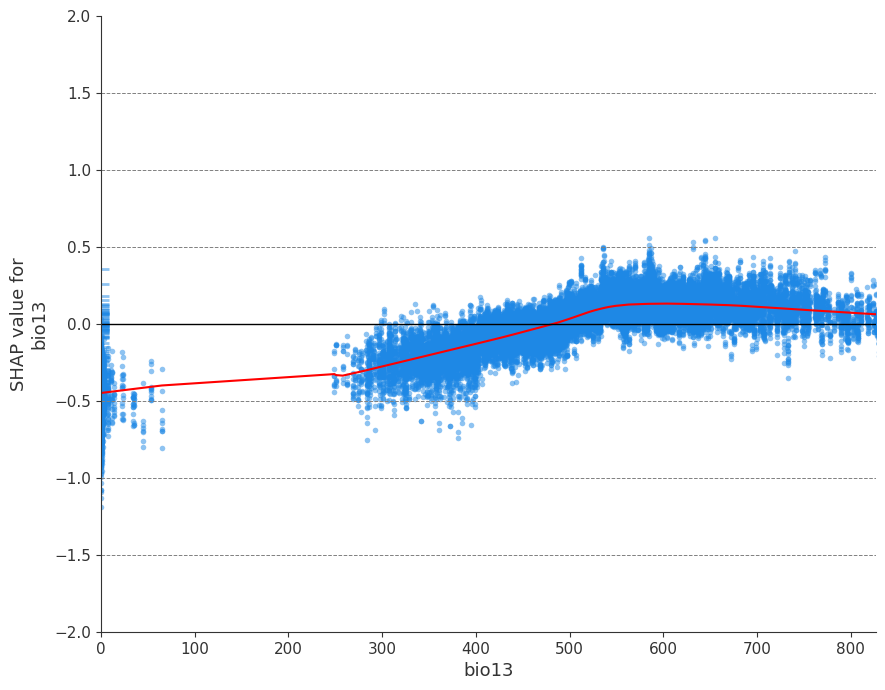

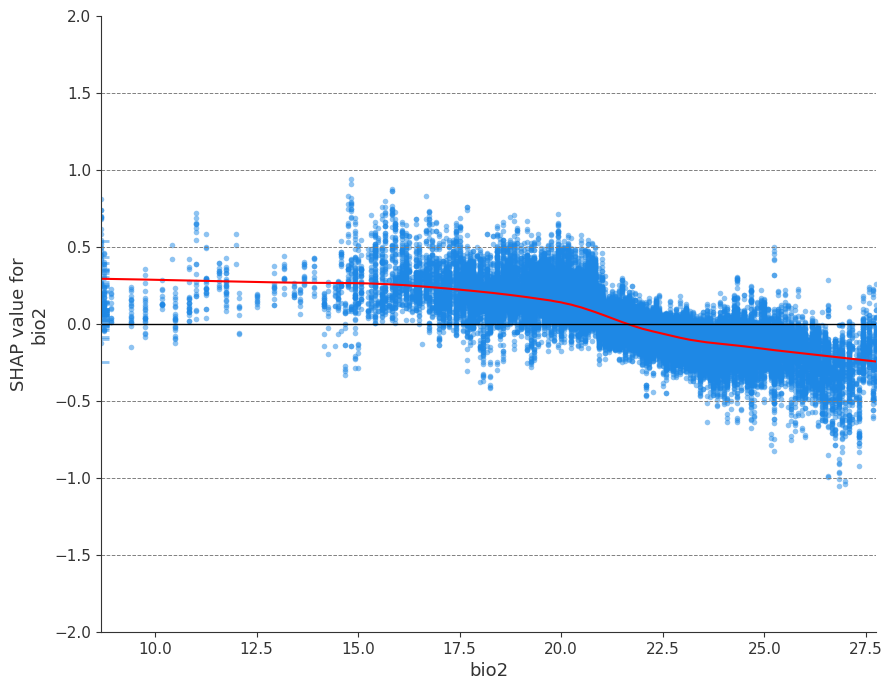

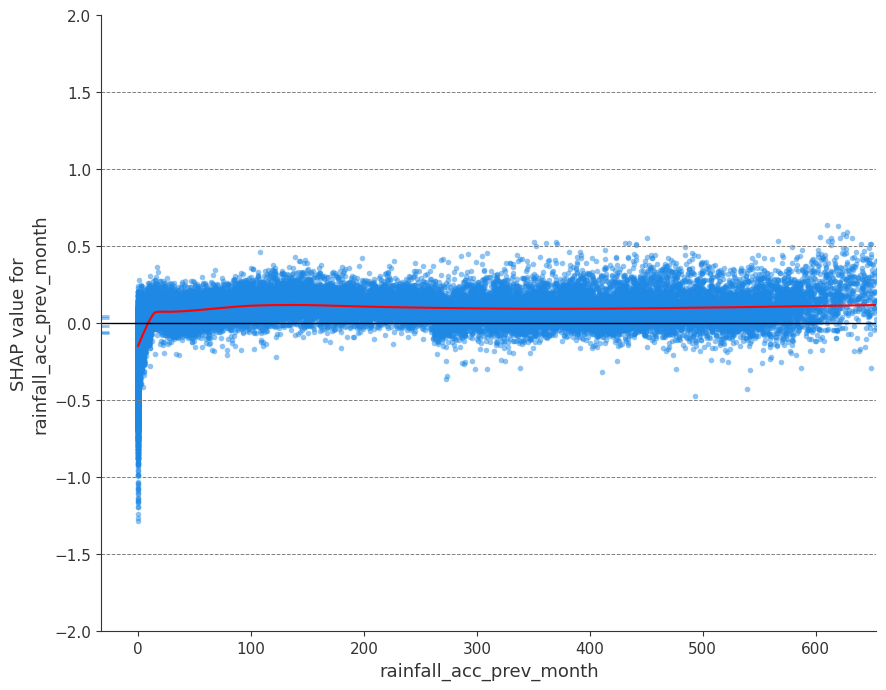

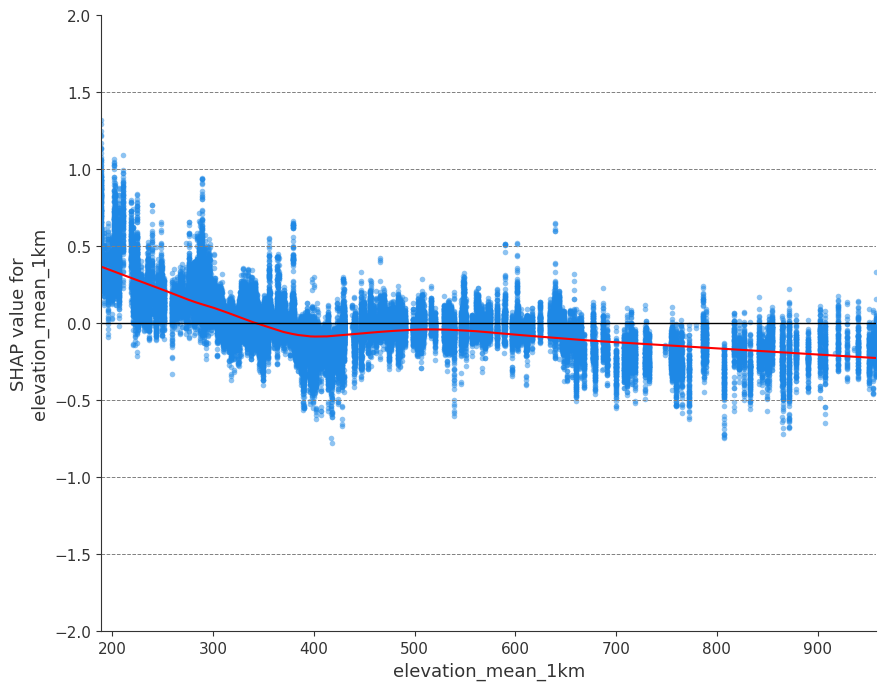

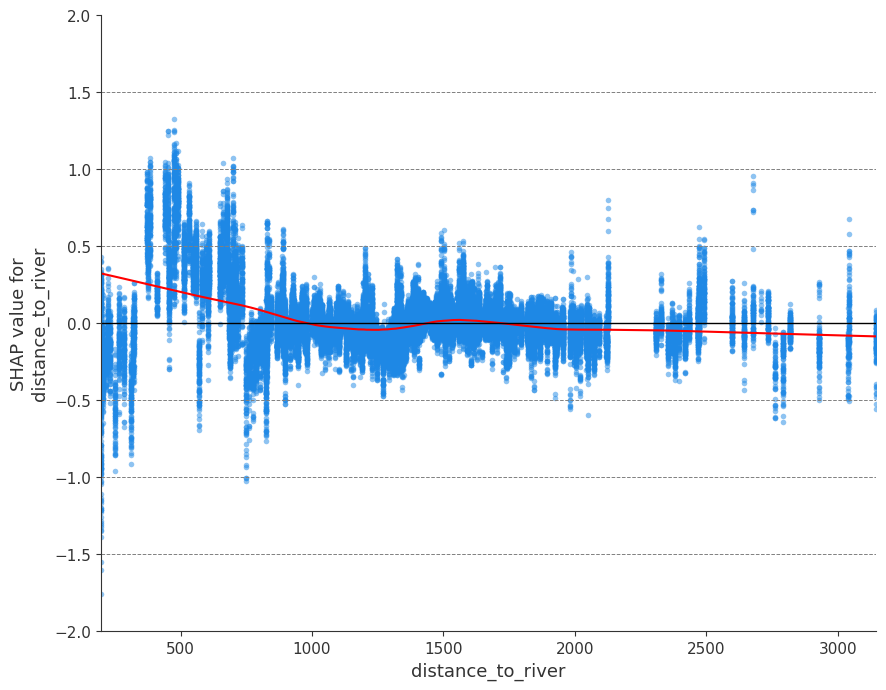

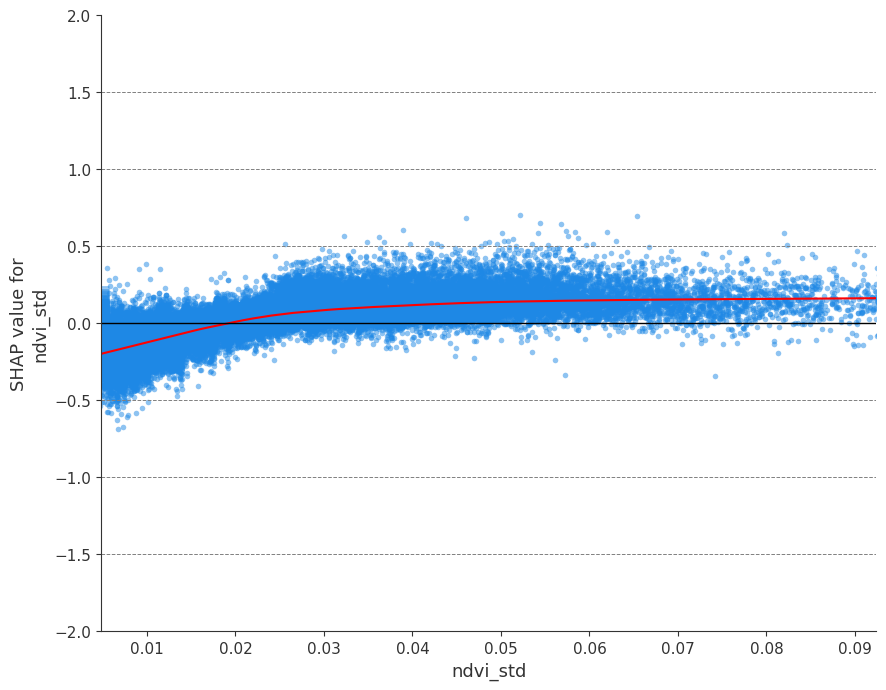

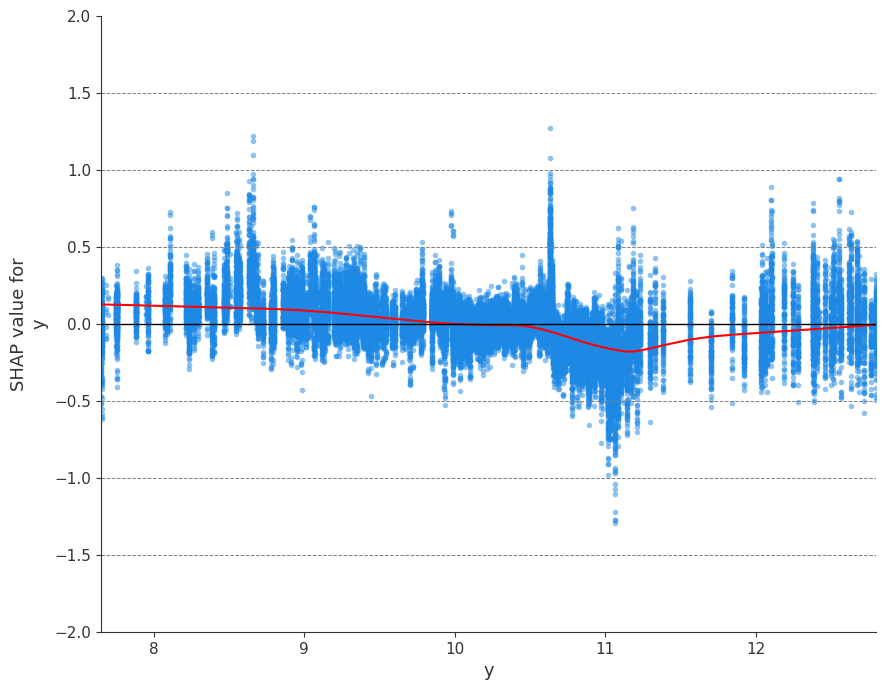

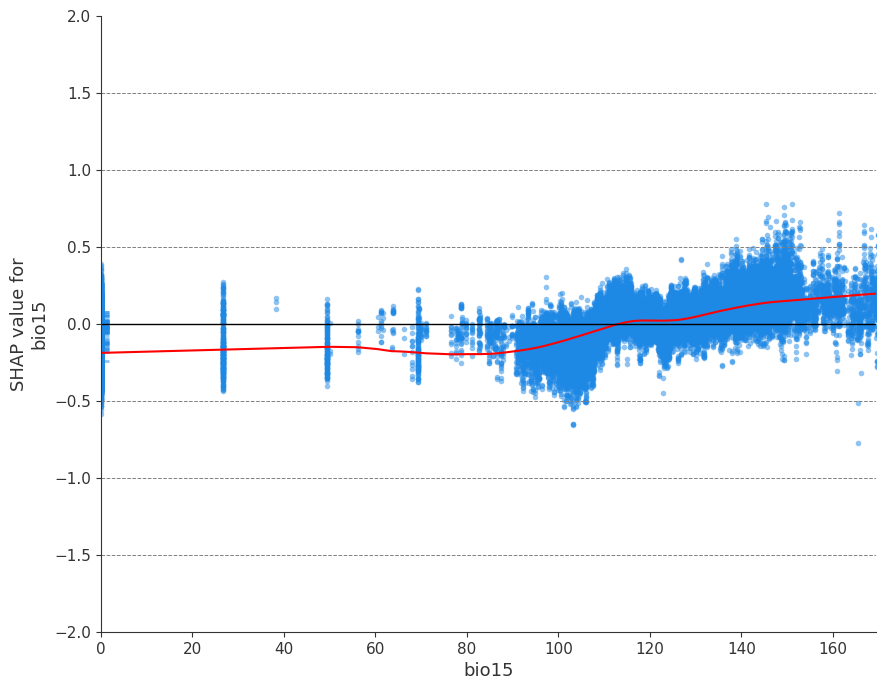

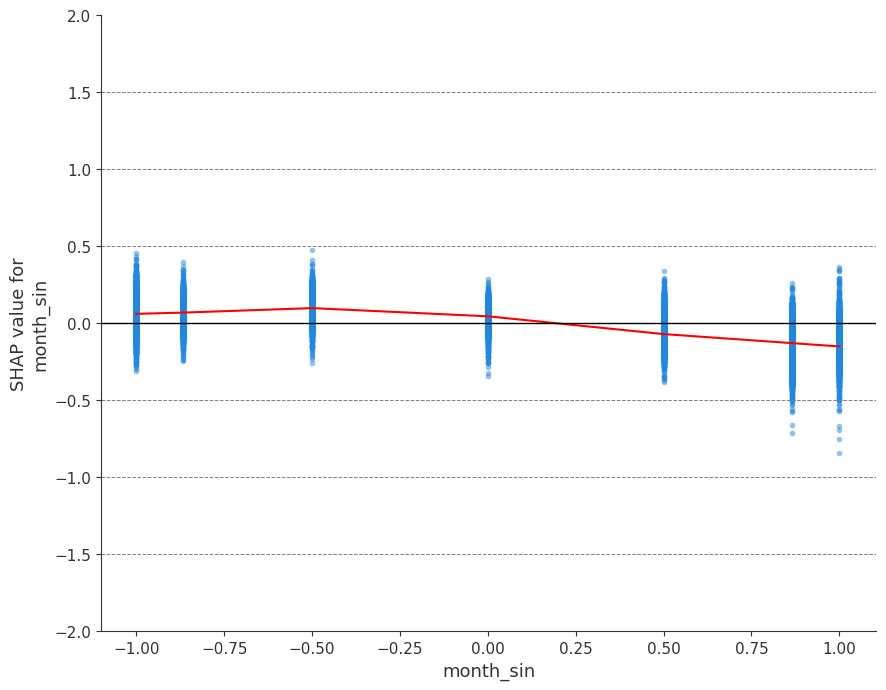

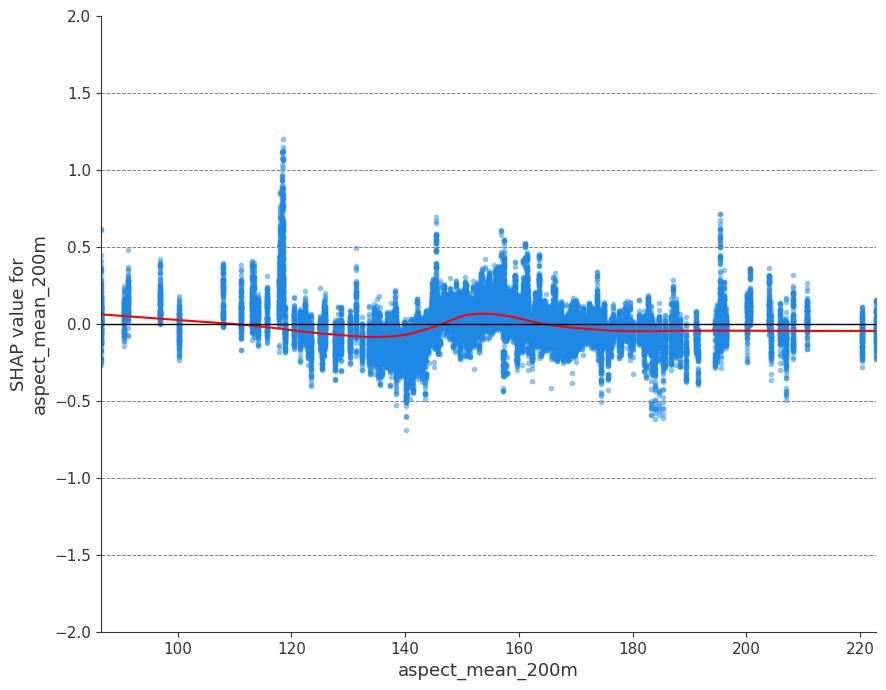

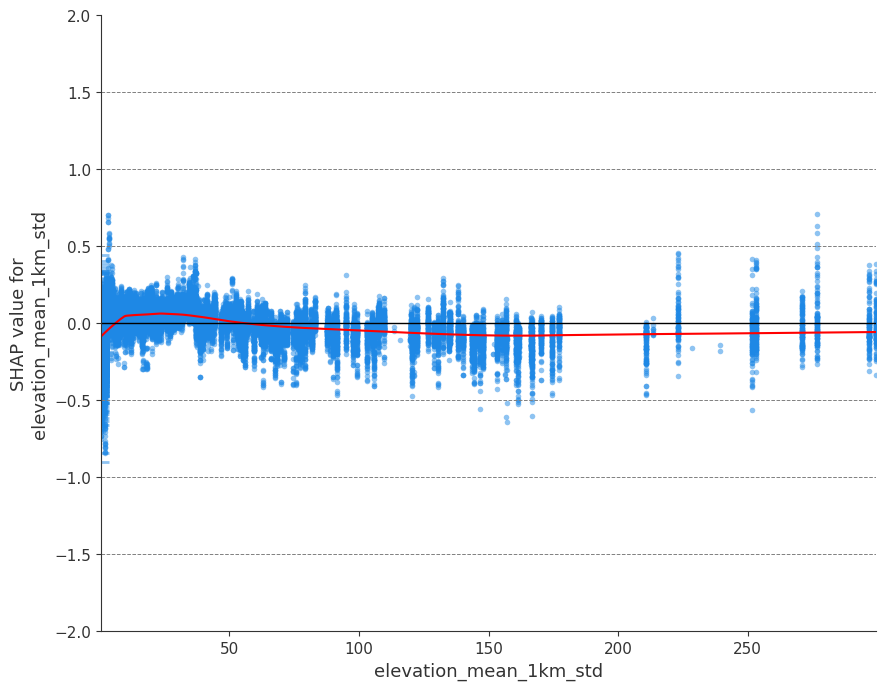

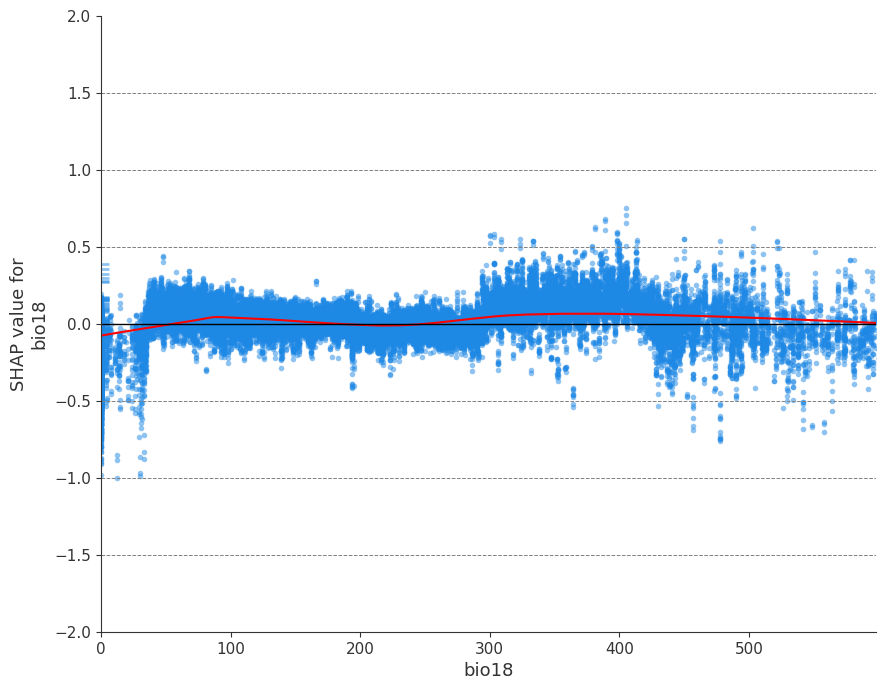

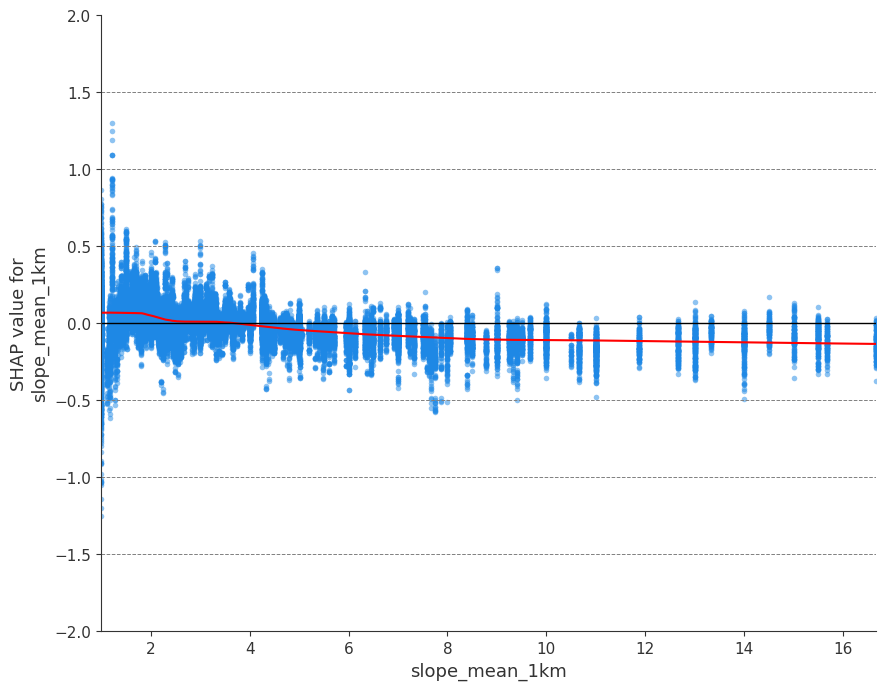

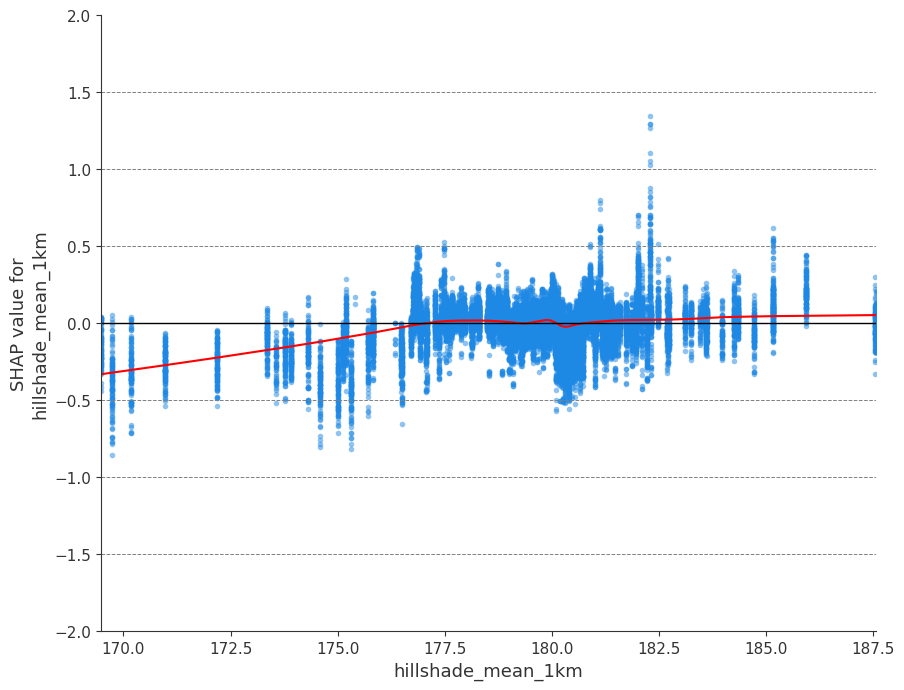

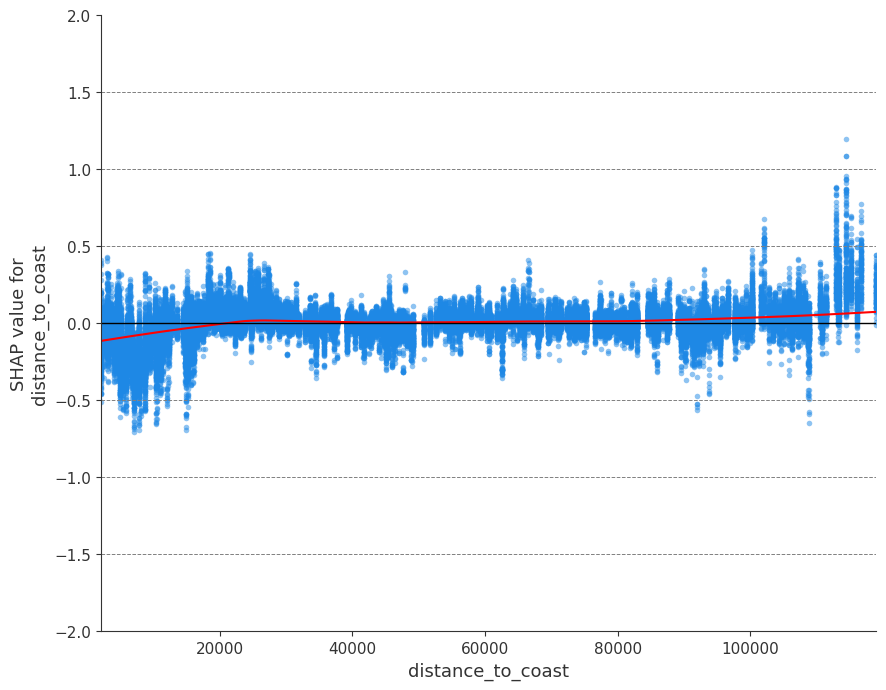

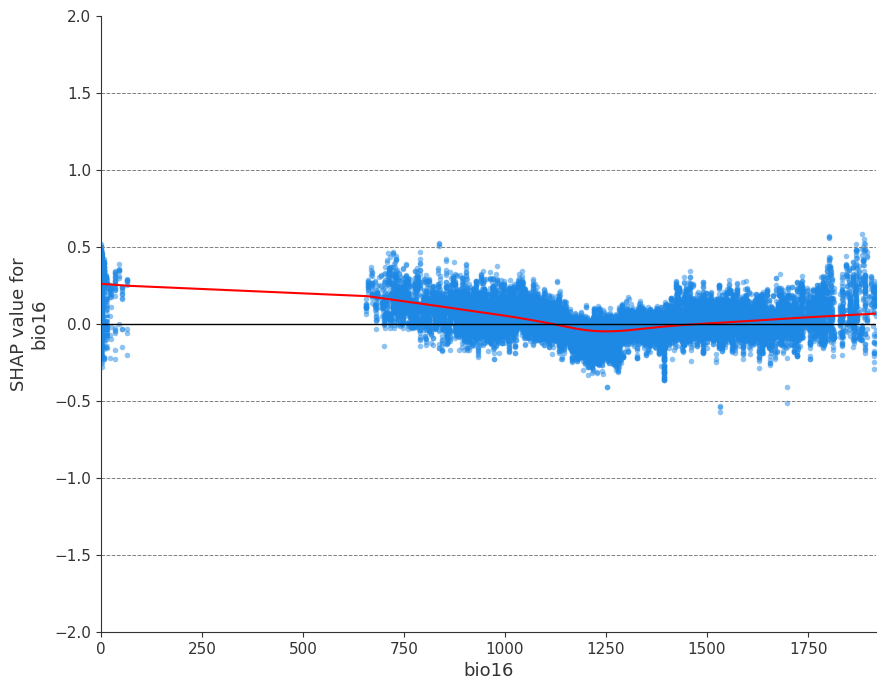

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning:

invalid value encountered in divide



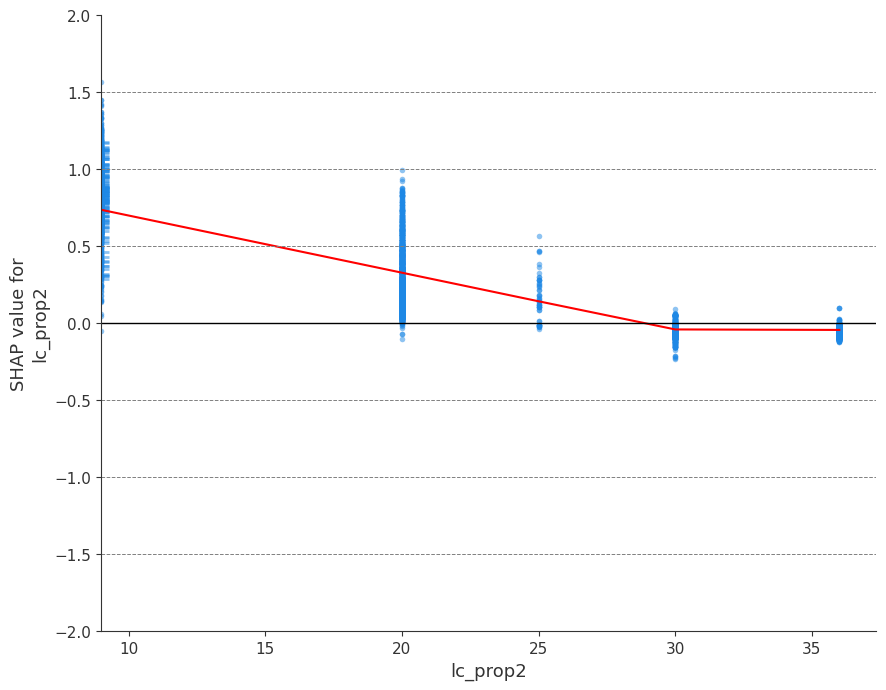

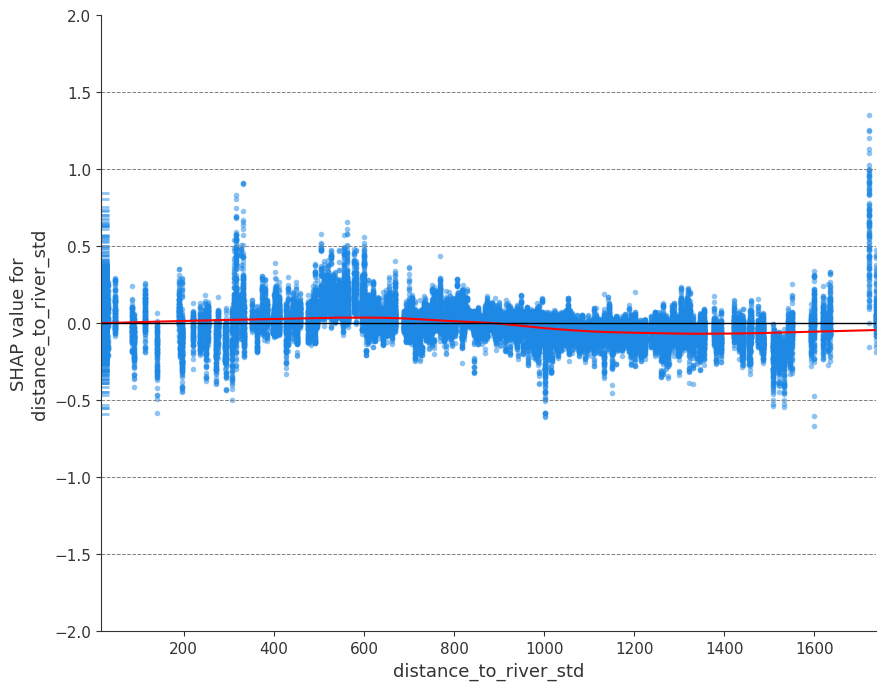

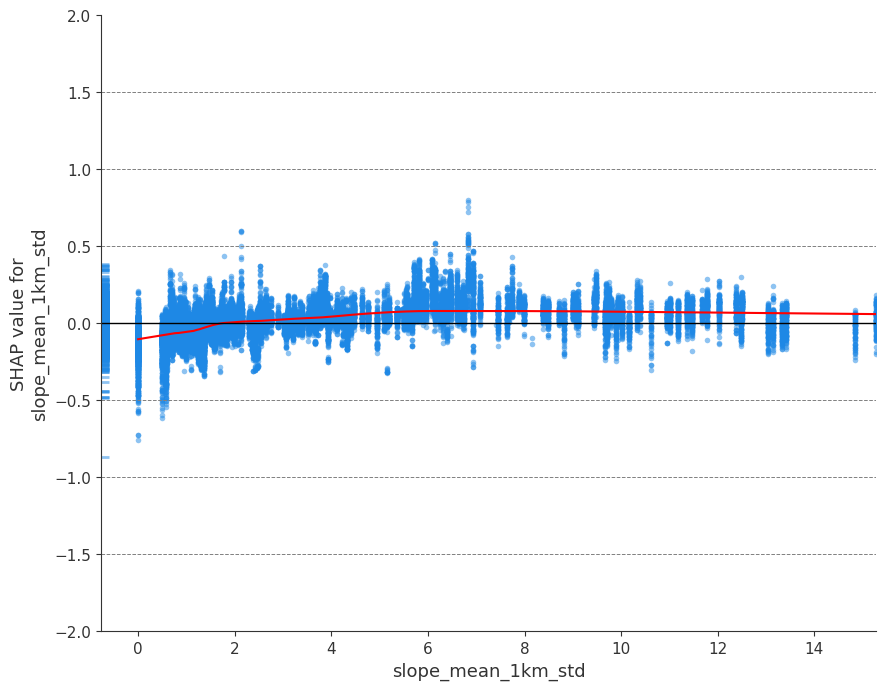

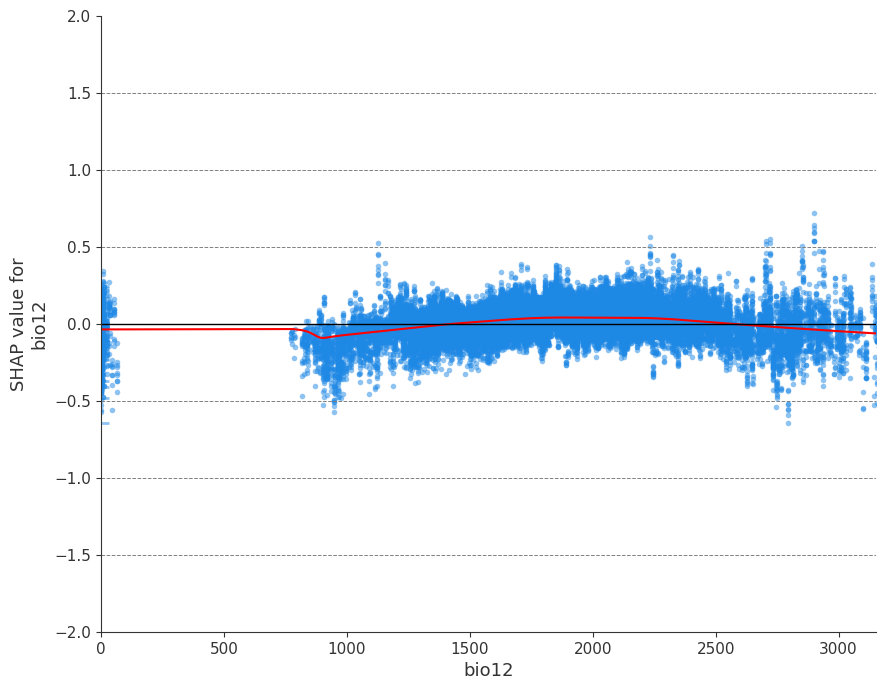

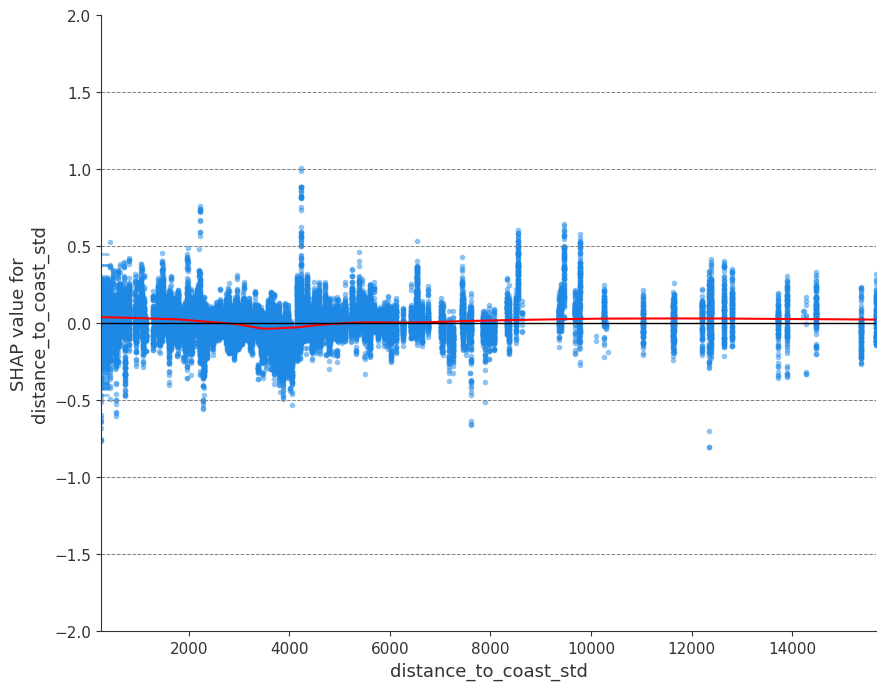

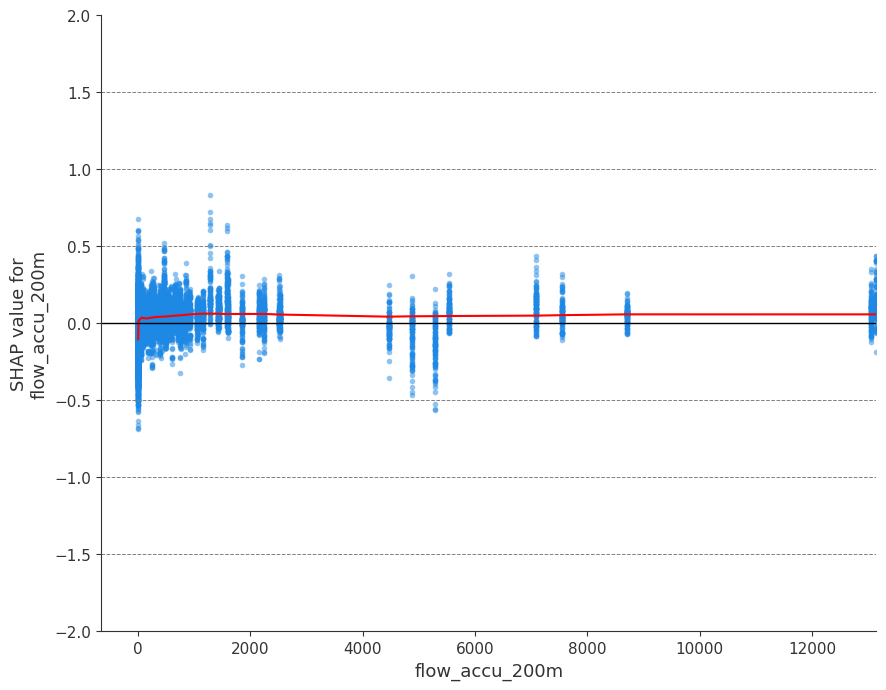

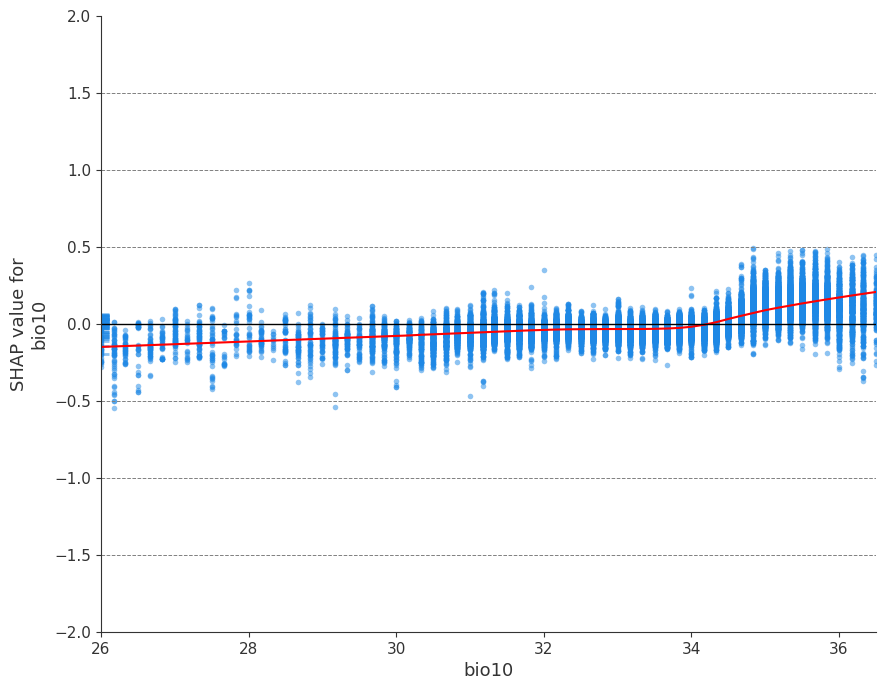

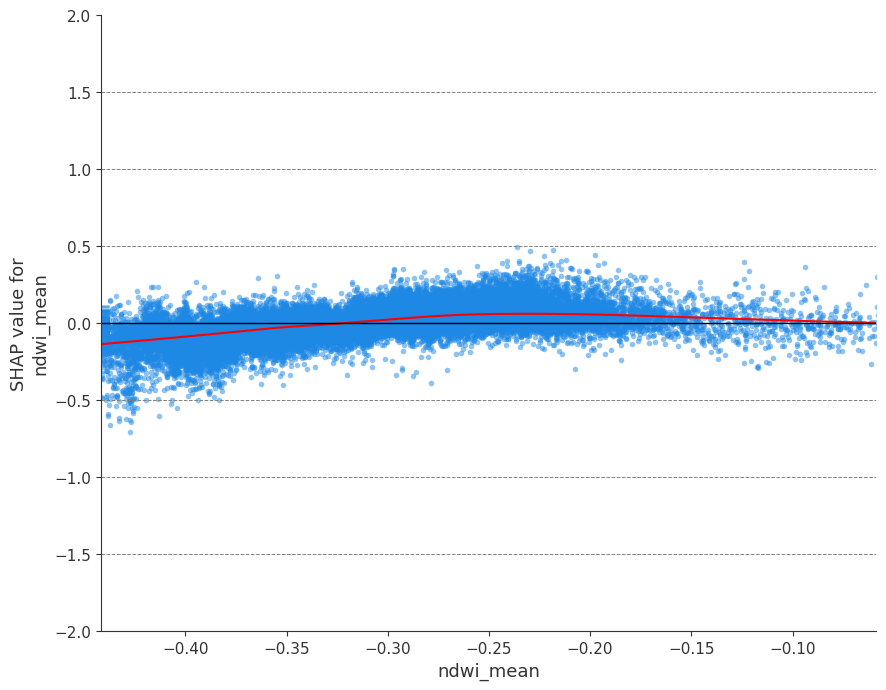

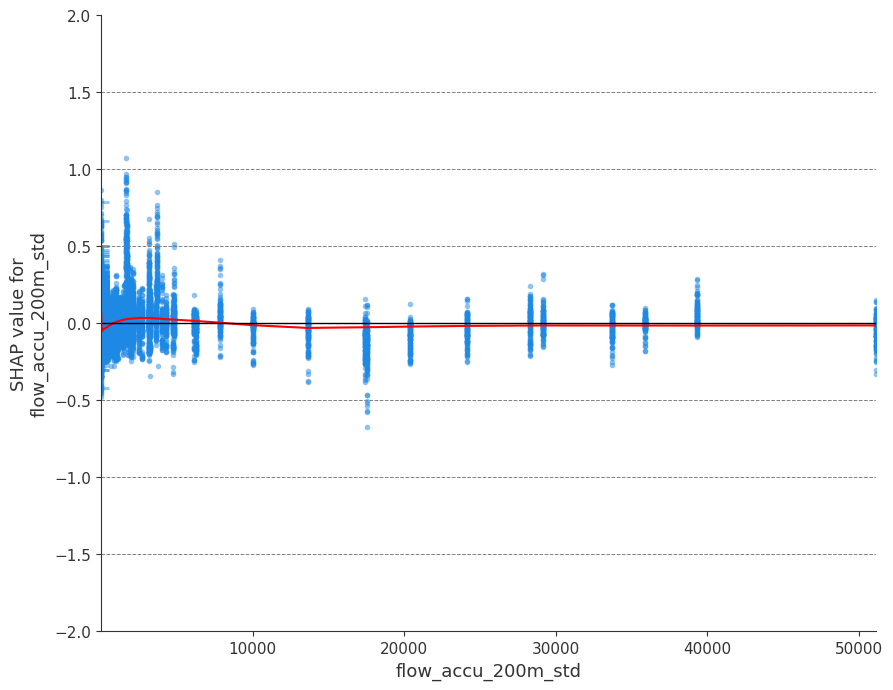

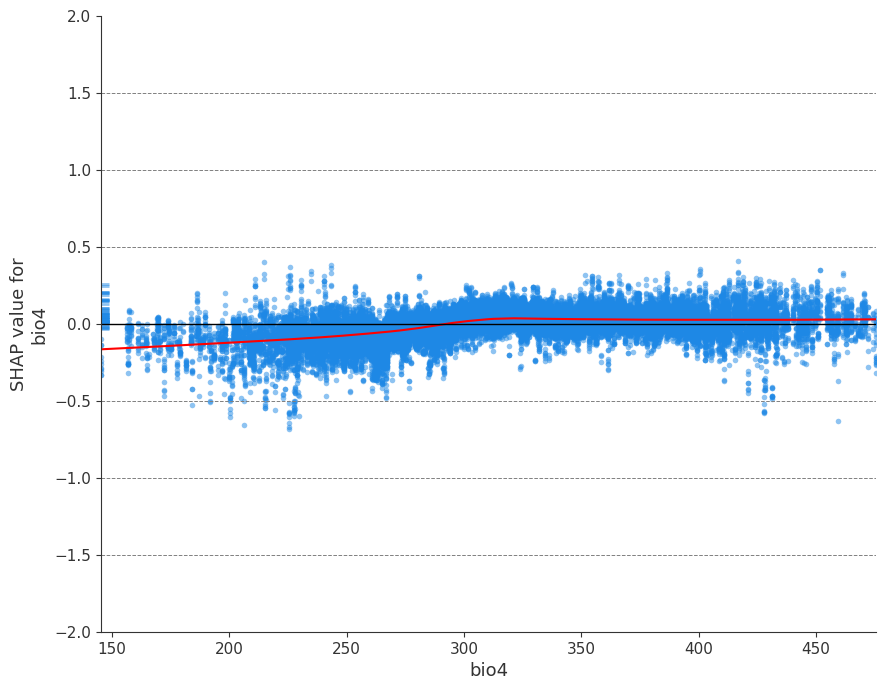

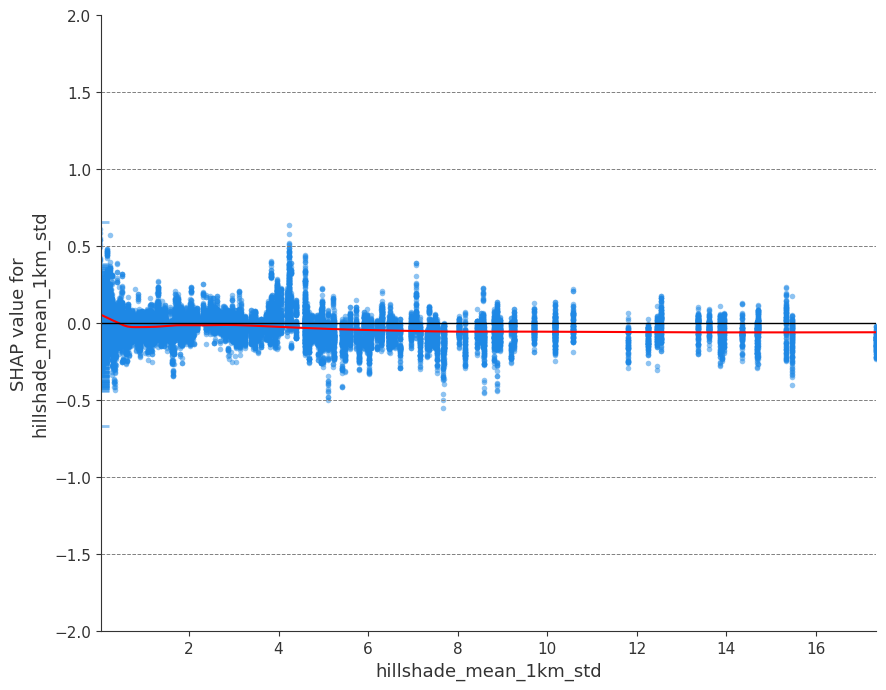

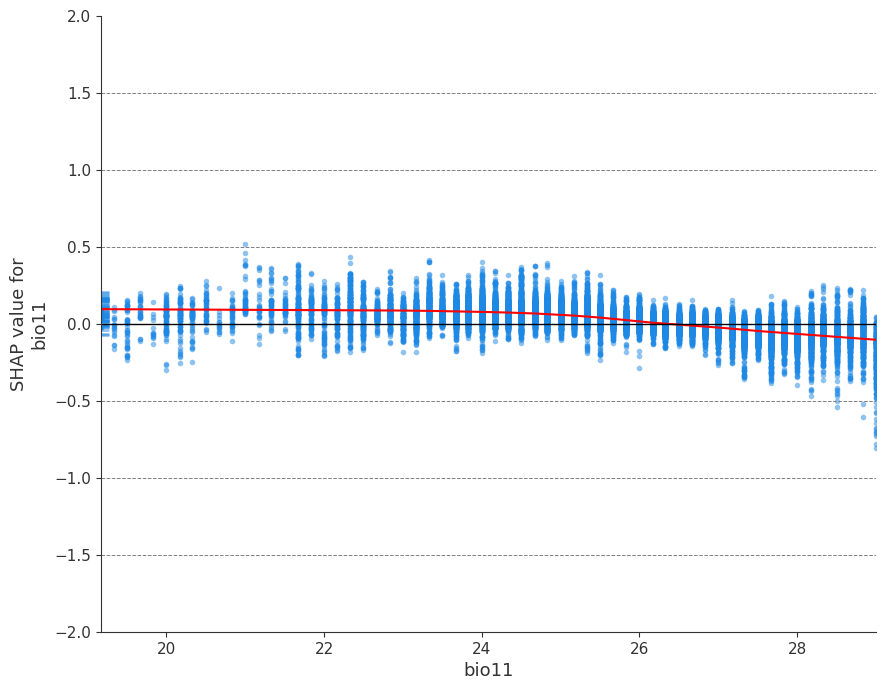

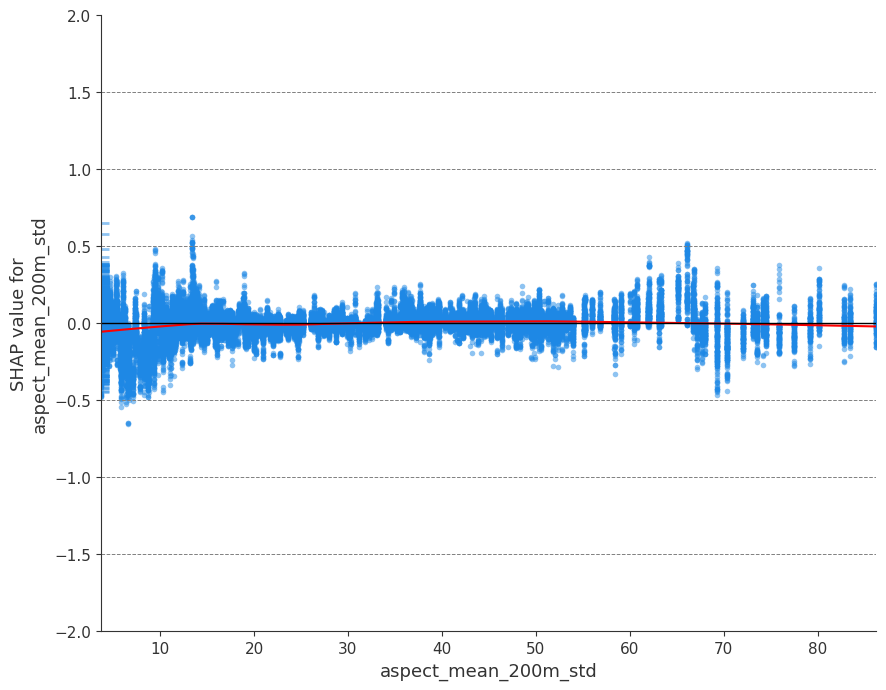

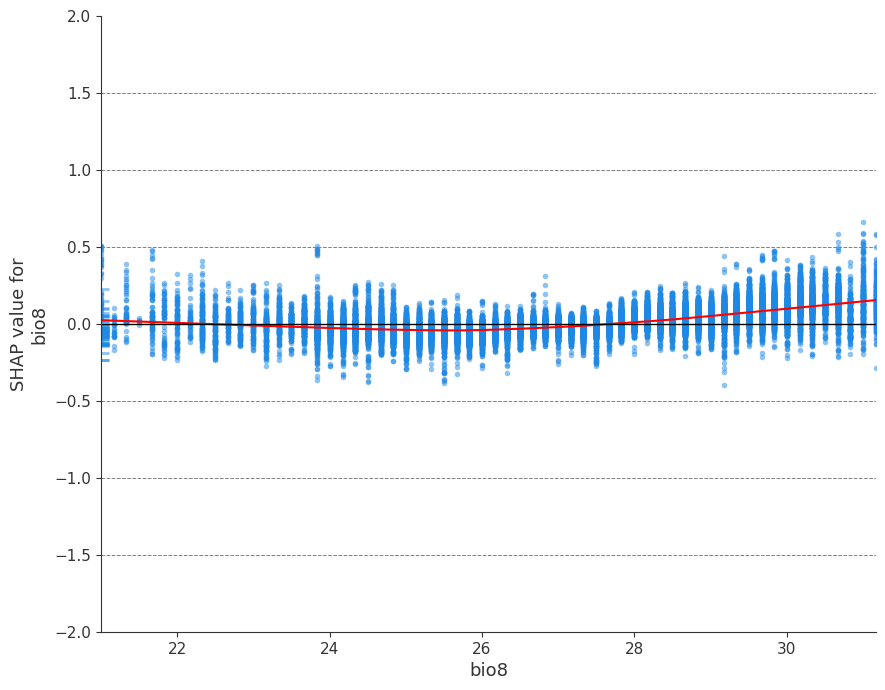

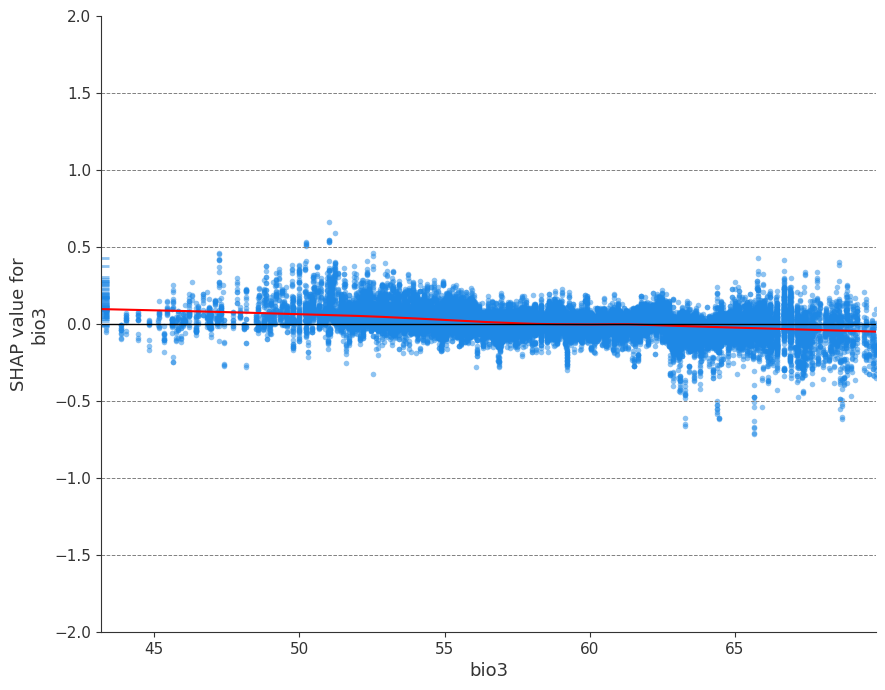

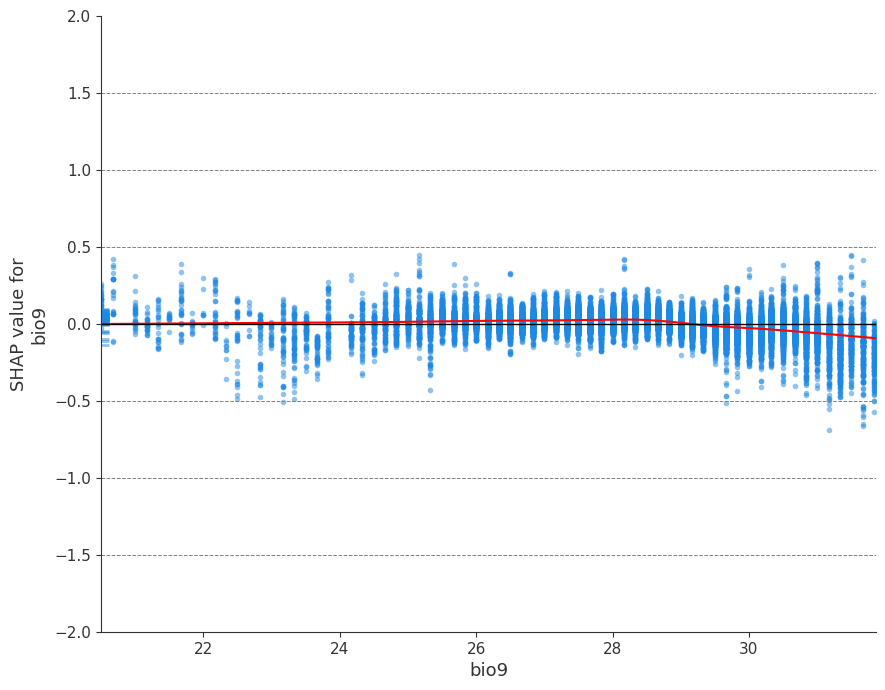

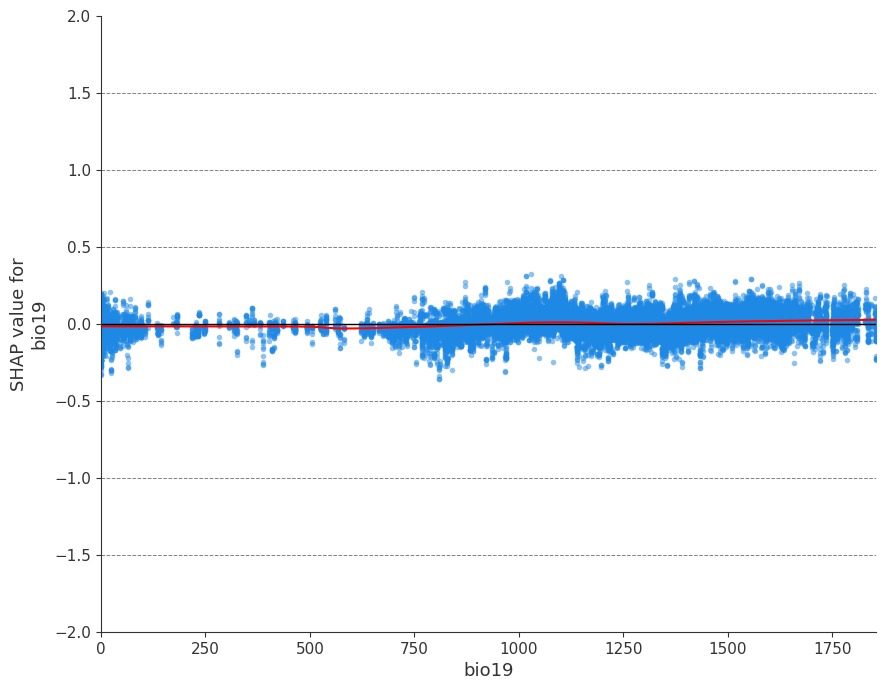

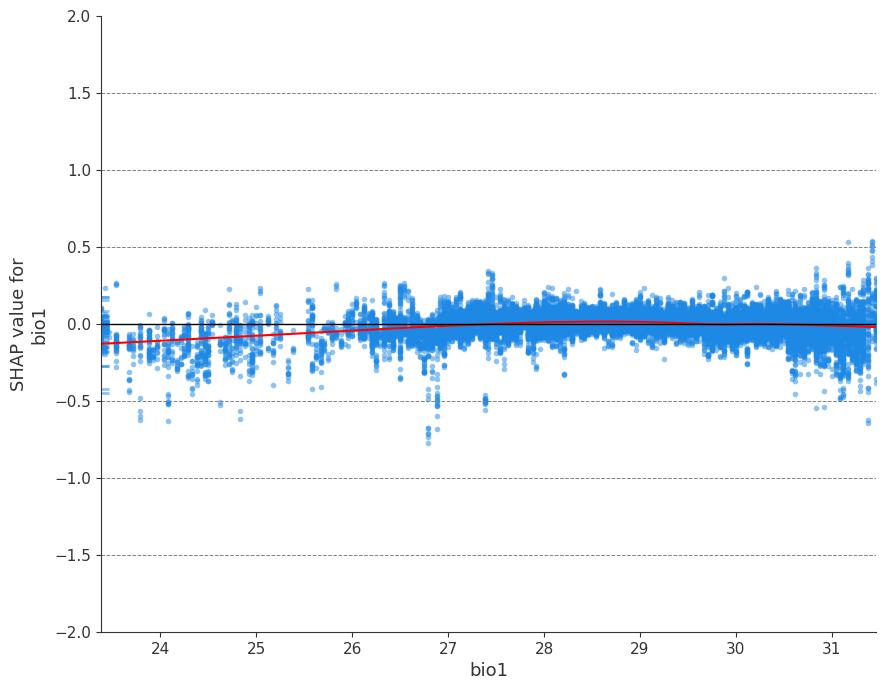

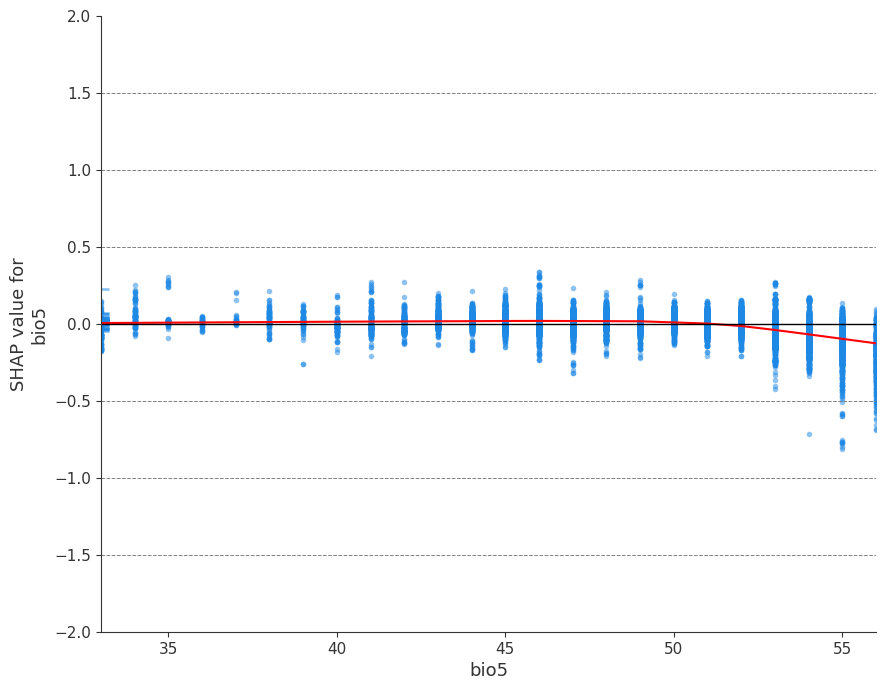

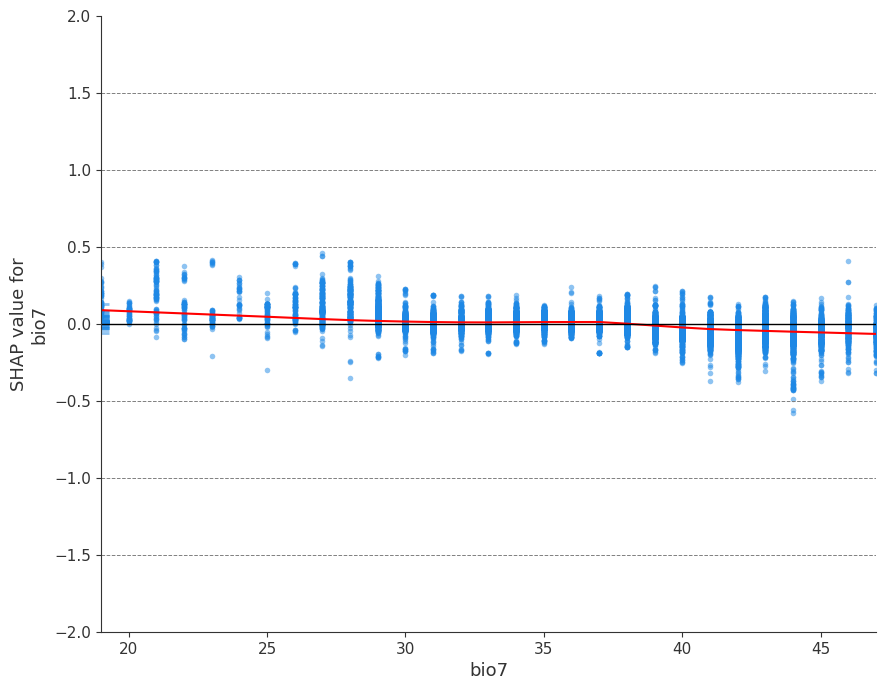

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning:

invalid value encountered in divide



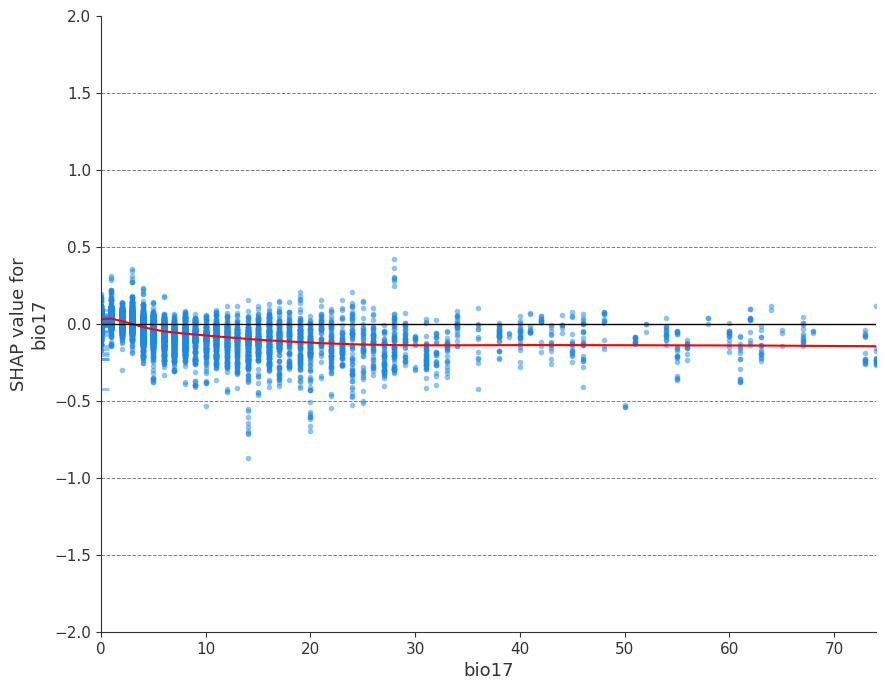

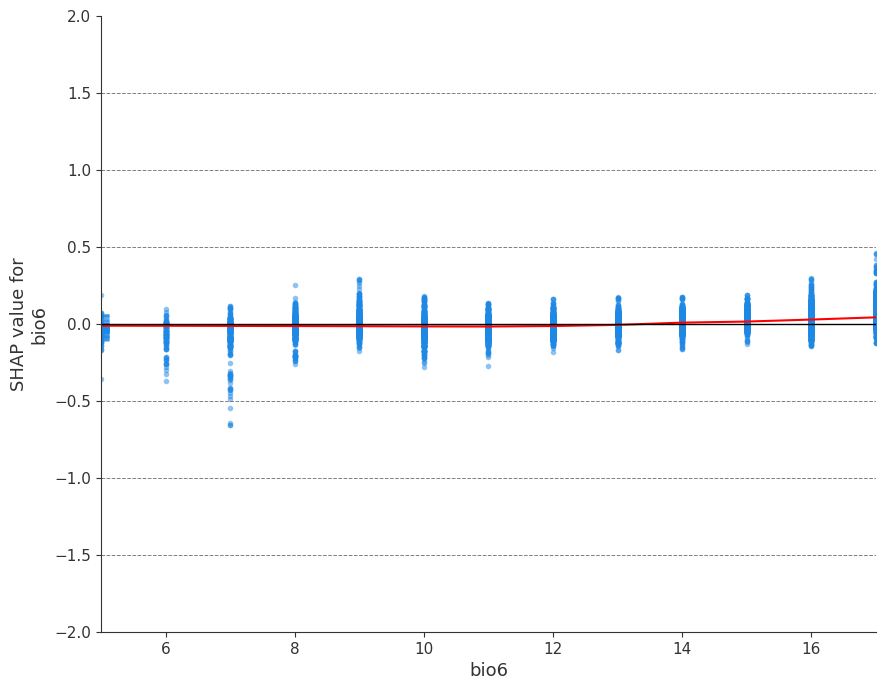

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning:

invalid value encountered in divide



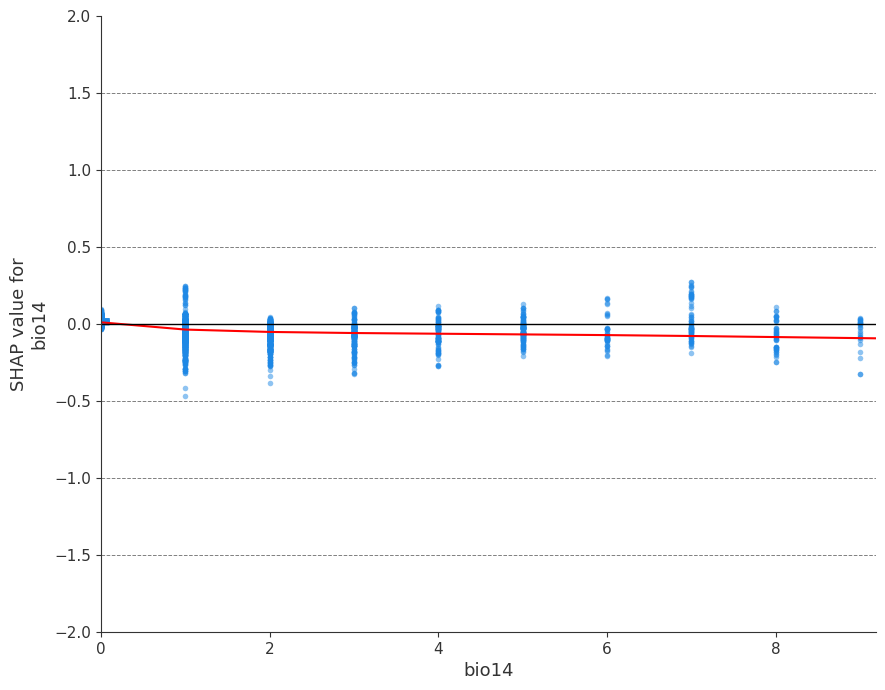

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning:

invalid value encountered in divide



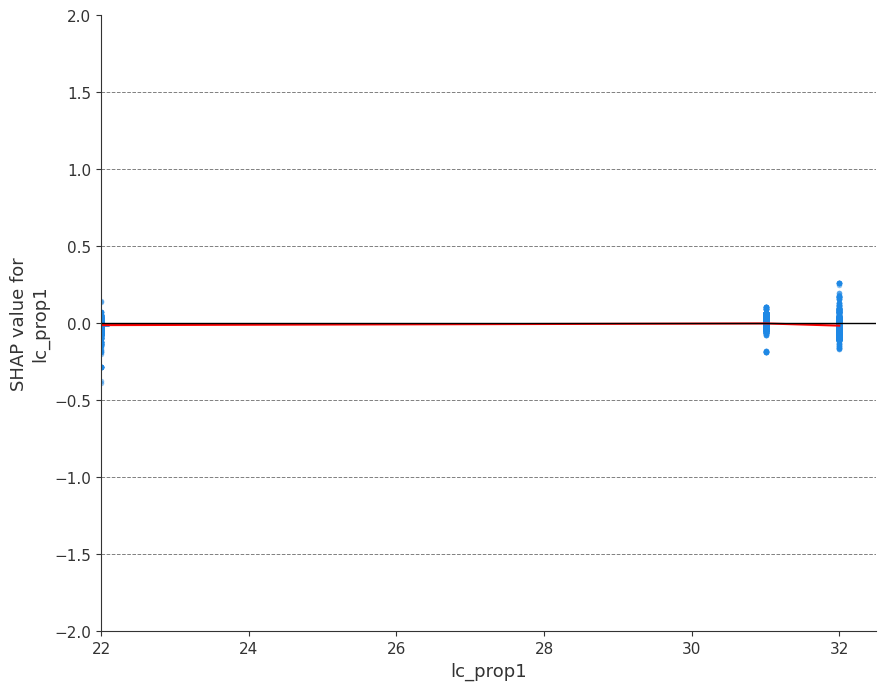

In [34]:
for ft in sorted_mean_abs_values_idx:
    feature = ft
    shap_values = shap_values
    data = X_test
    feature_names = X_test.columns

    idx = np.where(X_test.columns==feature)[0][0]
    x = X_test.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    fig,ax = plt.subplots(figsize=(10, 8))
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=1.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=1, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=0.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=0, color='black', linestyle='-', lw=1)
    ax.axhline(y=-0.5, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=-1, color='grey', linestyle='--', lw=0.7)
    ax.axhline(y=-1.5, color='grey', linestyle='--', lw=0.7)
    
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_test, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax = ax)